In [5]:
import os
import sys
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
#import nipes_data_fcts as nidf
import me_data_fcts as medf
#from statannotations.Annotator import Annotator
import scipy.sparse
import sympy
import sklearn.datasets
import sklearn.feature_extraction.text
import umap
import umap.plot
import matplotlib.pyplot as plt
from numpy.random import rand
from numpy import genfromtxt
%matplotlib inline

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/local/lib/python3.10/dist-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/usr/local/lib/python3.10/dist-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.

In [6]:
repo_folder = "/are/logs/are/meim_env_pressure_alife/"
experiments = {
    "directory" :  ['meimflat', 'meimhill', 'meimholes', 'meimholly', 'meimobs', 'meimrough' ],
    "name" :       ['flat', 'hill', 'holes', 'hollyrood', 'objects', 'rough'],
    "print_name" : ['Flat', 'Hill', 'Holes', 'Hollyrood', 'Objects', 'Rough']
}

In [7]:
def load_sparse_morph(name, folders):
  _robots_loaded = 0
  _morph_sparse = []
  _morph_fitness = np.empty((0))
  _morph_labels = []
  for folder in folders:
      print(folder)
      _morph_dense = genfromtxt(folder + '/morph_descriptor.csv', delimiter=',')
      _morph_fit = genfromtxt(folder + '/fitness.csv', delimiter=',')[:,3]
      assert _morph_dense.shape[0] == _morph_fit.shape[0]
      print(_morph_dense.shape)
      _morph_fit = _morph_fit / np.max(_morph_fit)
      _morph_fitness = np.append(_morph_fitness, _morph_fit, axis=0)
      _robots_loaded += _morph_dense.shape[0]
      if _morph_sparse == []:
          _morph_sparse = scipy.sparse.lil_matrix(_morph_dense[:, 2:])
      else:
          temp_sparse = scipy.sparse.lil_matrix(_morph_dense[:, 2:])
          print("temp_sparse", temp_sparse.shape)
          _morph_sparse = scipy.sparse.vstack([_morph_sparse, temp_sparse])
      print("sparse", _morph_sparse.shape)
  _morph_labels = np.array([name] * _robots_loaded)
  return _morph_sparse, _morph_fitness, _morph_labels, _robots_loaded

In [8]:
morph_labels = []
morph_sparse = []
morph_fitness = np.empty((0))
robots_loaded = 0
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        for fold in os.listdir(repo_folder + exps + '/' + folder):
            folders.append(repo_folder + exps + '/' + folder + '/' + fold)
    _ms, _mf, _ml, _rl = load_sparse_morph(experiments['name'][idx], folders)
    robots_loaded += _rl
    if morph_sparse == []:
      morph_sparse = _ms
    else:
      morph_sparse = scipy.sparse.vstack([morph_sparse, _ms])
    print("morph_sparse", morph_sparse.shape)
    morph_fitness = np.append(morph_fitness, _mf, axis=0)
    morph_labels = np.append(morph_labels, _ml, axis=0)
print(morph_fitness.shape)
print(len(morph_labels))
print(morph_sparse.shape)
print(robots_loaded) 

meimflat
/are/logs/are/meim_env_pressure_alife/meimflat/55502_4/meim_5_3_19-21-49-9576-2461188757
(5054, 1333)
sparse (5054, 1331)
/are/logs/are/meim_env_pressure_alife/meimflat/55502_2/meim_5_3_19-21-45-5953-2557405441
(5040, 1333)
temp_sparse (5040, 1331)
sparse (10094, 1331)
/are/logs/are/meim_env_pressure_alife/meimflat/55502_3/meim_5_3_19-21-47-7590-3762515728
(5033, 1333)
temp_sparse (5033, 1331)
sparse (15127, 1331)
/are/logs/are/meim_env_pressure_alife/meimflat/55460_1/meim_4_3_20-52-40-260-3818833982
(5001, 1333)
temp_sparse (5001, 1331)
sparse (20128, 1331)
/are/logs/are/meim_env_pressure_alife/meimflat/55502_1/meim_5_3_19-21-47-7137-980365812
(5041, 1333)
temp_sparse (5041, 1331)
sparse (25169, 1331)
morph_sparse (25169, 1331)
meimhill
/are/logs/are/meim_env_pressure_alife/meimhill/55507_2/meim_6_3_0-42-15-5931-2400538420
(5030, 1333)
sparse (5030, 1331)
/are/logs/are/meim_env_pressure_alife/meimhill/55507_4/meim_6_3_1-16-4-4789-921363248
(5002, 1333)
temp_sparse (5002, 1331

In [9]:
print(morph_fitness.shape)
print(morph_labels.shape)
print(morph_sparse.shape)
print(robots_loaded) 
np.min(morph_fitness)

(150635,)
(150635,)
(150635, 1331)
150635


0.0

In [10]:
%%time
mapper = umap.UMAP(metric='manhattan', low_memory=True).fit(morph_sparse)

/usr/local/lib/python3.10/dist-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


CPU times: user 20min 29s, sys: 30min 53s, total: 51min 23s
Wall time: 3min 5s


(799.5, -0.5)

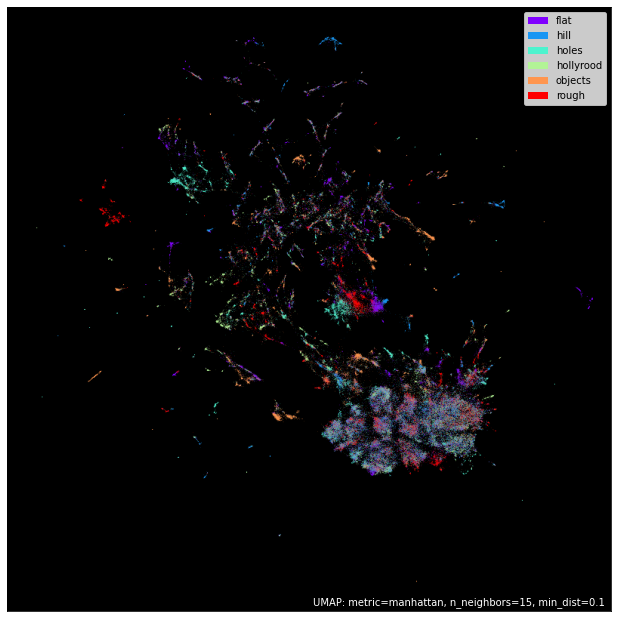

In [135]:
full_plot = umap.plot.points(mapper, labels=morph_labels, theme='darkred') #values=np.arange(morph_sparse.shape[0]), )
#full_plot_xlim = full_plot.ax.get_xlim()
#full_plot_ylim = full_plot.ax.get_ylim()
full_plot.get_xlim()
full_plot.get_ylim()

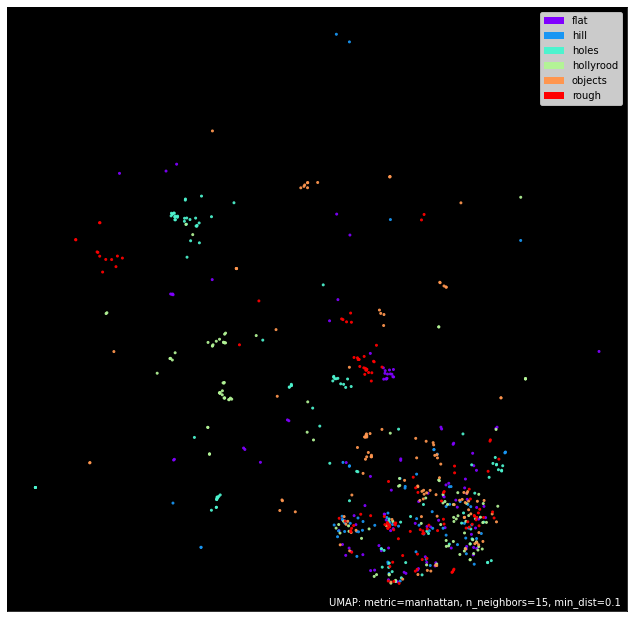

In [134]:
ss = np.greater(morph_fitness, 0.7)
the_plot = umap.plot.points(mapper, labels=morph_labels, subset_points=ss, theme='darkred',alpha=0.9) #values=np.arange(morph_sparse.shape[0]), )
#the_plot.set_xlim(full_plot_xlim)
#the_plot.set_ylim(full_plot_ylim)
#print(the_plot.get_xlim()[0])
#print(full_plot_xlim)

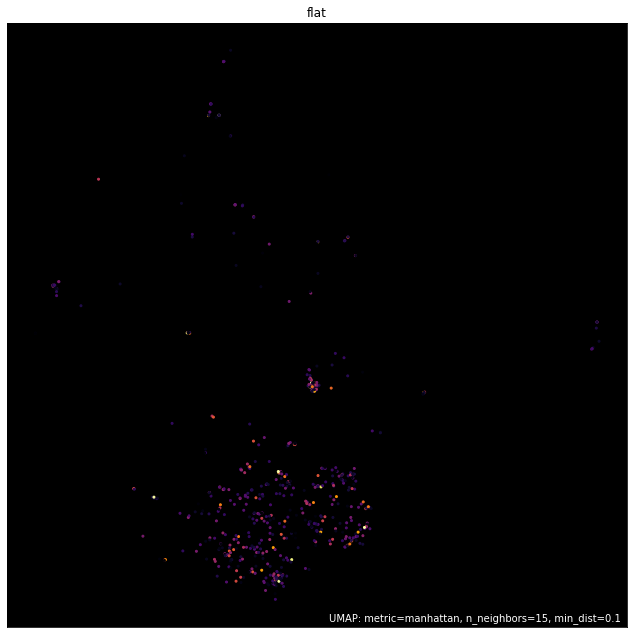

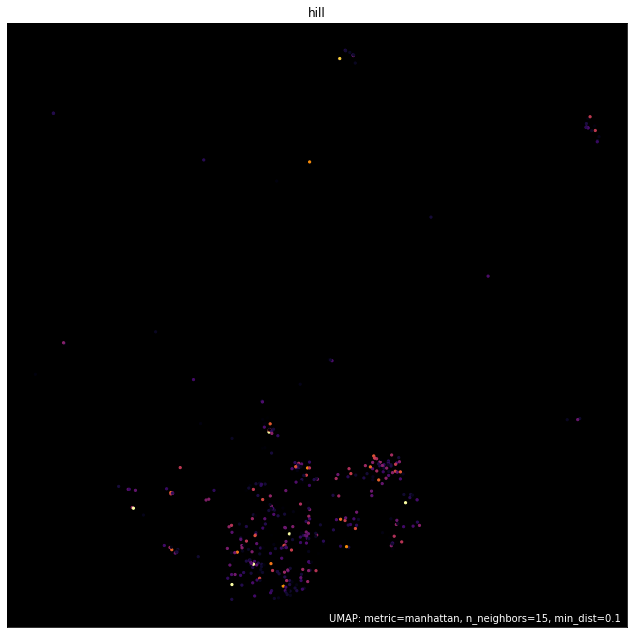

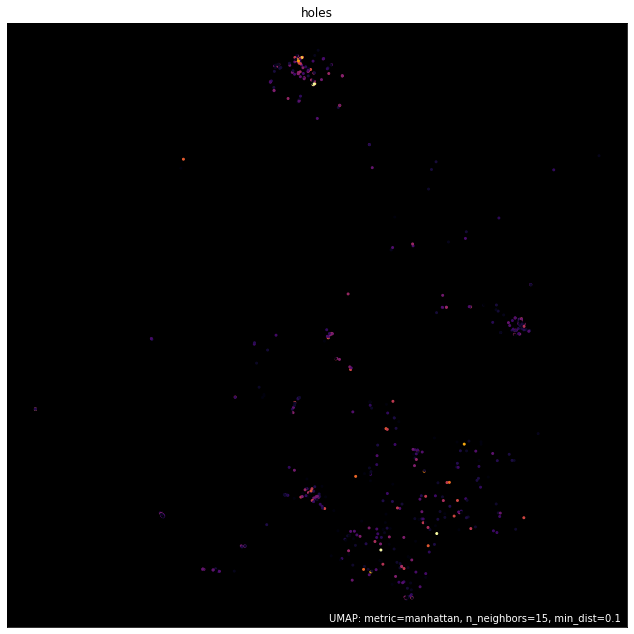

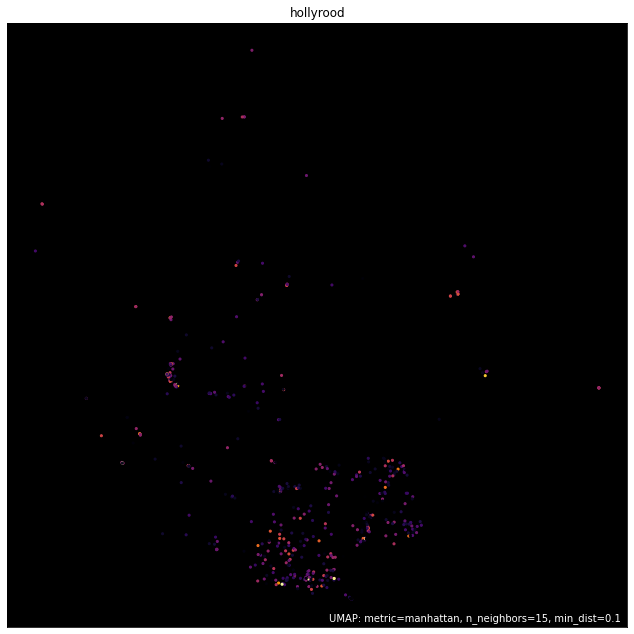

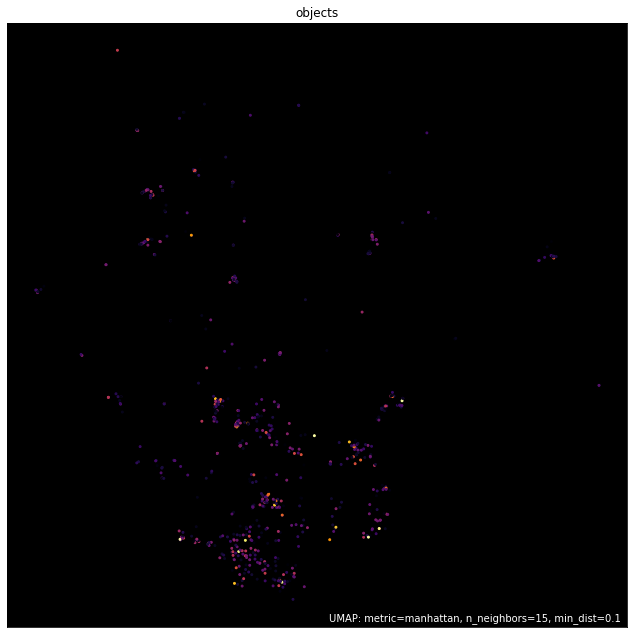

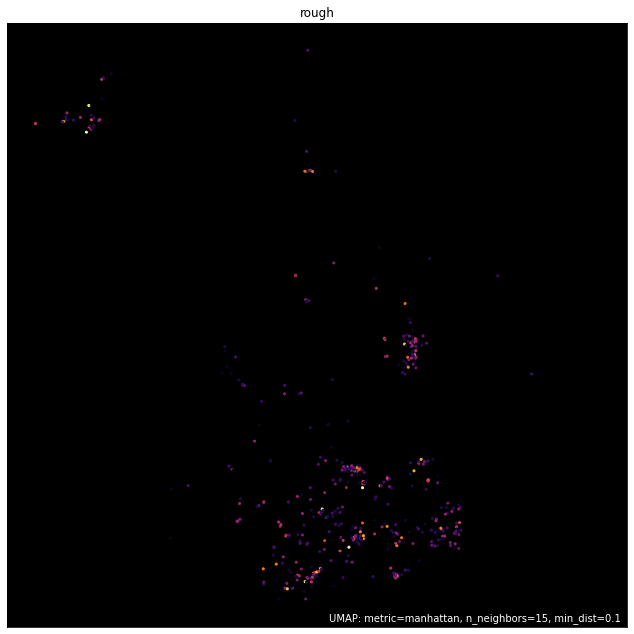

In [33]:
for n in experiments['name']:
    ss = np.equal(morph_labels, n) * np.greater(morph_fitness, 0.5)
    the_plot = umap.plot.points(mapper, values=morph_fitness, subset_points=ss, theme='inferno') #values=np.arange(morph_sparse.shape[0]), )
    the_plot.set_title(n)
#the_plot.set_xlim(-0.5,799.5)
#the_plot.set_ylim(799.5,-0.5)

In [30]:
ss = np.greater(morph_fitness, 0.5)
#ss_fit = morph_fitness[ss > 0]
#the_plot = umap.plot.points(mapper, labels=morph_labels, subset_points=ss, theme='darkred',alpha=0.9) #values=np.arange(morph_sparse.shape[0]), )

p = umap.plot.interactive(mapper, subset_points=ss, labels=morph_labels, hover_data=morph_fitness, point_size=2)
umap.plot.show(p)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [31]:
morph_fitness

array([0.342592  , 0.05555556, 0.03703704, ..., 0.30555591, 0.13888853,
       0.24999964])

In [237]:
%%time
mapper_euclidean = umap.UMAP(metric='euclidean', low_memory=True).fit(morph_sparse)

CPU times: user 47min 23s, sys: 4.72 s, total: 47min 28s
Wall time: 5min 32s


<Axes: >

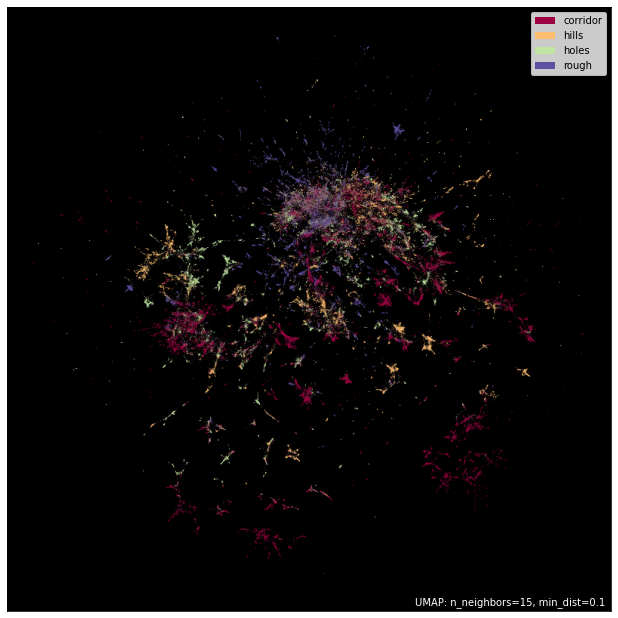

In [238]:
umap.plot.points(mapper_euclidean, labels=morph_labels, theme='inferno') #values=np.arange(morph_sparse.shape[0]), )

In [239]:
%%time
mapper_canberra = umap.UMAP(metric='canberra', low_memory=True).fit(morph_sparse)

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


CPU times: user 1h 18min 12s, sys: 6.82 s, total: 1h 18min 19s
Wall time: 11min 51s


<Axes: >

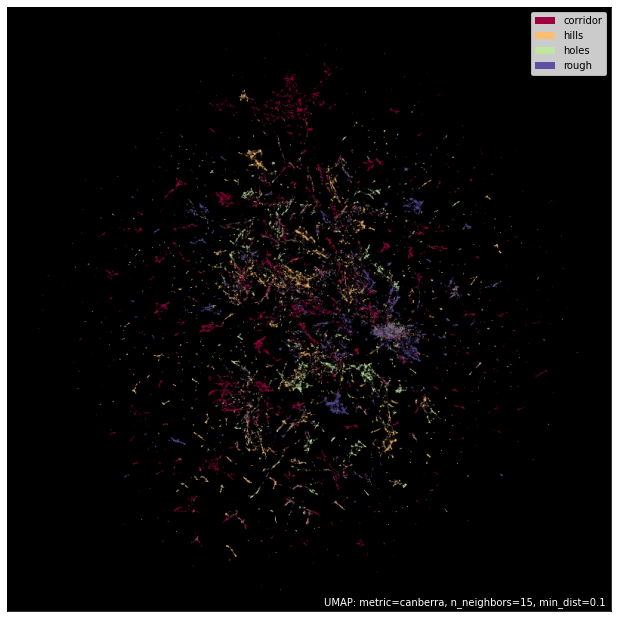

In [240]:
umap.plot.points(mapper_canberra, labels=morph_labels, theme='inferno') #values=np.arange(morph_sparse.shape[0]), )

In [241]:
%%time
mapper_manhattan = umap.UMAP(metric='manhattan', low_memory=True).fit(morph_sparse)

CPU times: user 1h 21min 21s, sys: 4.56 s, total: 1h 21min 26s
Wall time: 6min 43s


<Axes: >

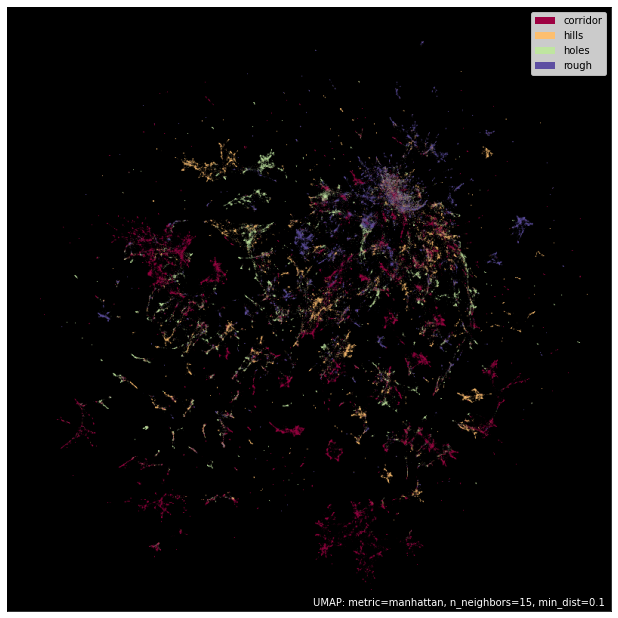

In [242]:
umap.plot.points(mapper_manhattan, labels=morph_labels, theme='inferno') #values=np.arange(morph_sparse.shape[0]), )

In [248]:
%%time
mapper_manhattan = umap.UMAP(metric='manhattan', low_memory=True, n_neighbors=5).fit(morph_sparse)

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.10/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/lib/python3.10/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling bac

CPU times: user 1h 11min 55s, sys: 3.64 s, total: 1h 11min 59s
Wall time: 4min 31s


<Axes: >

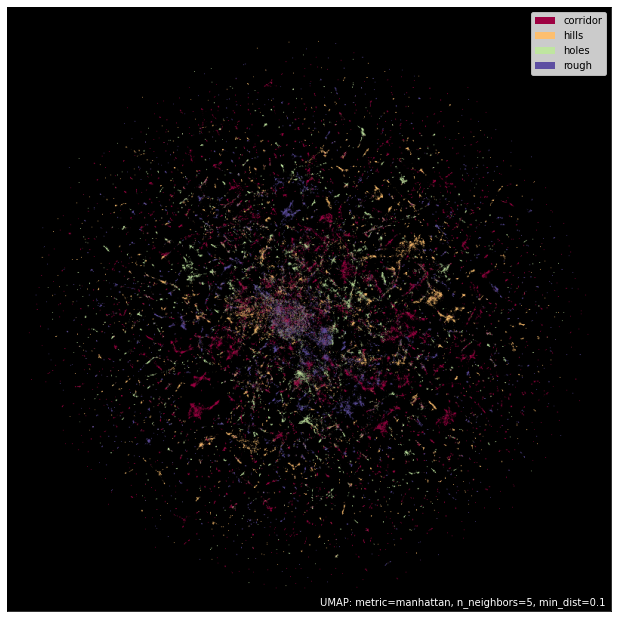

In [249]:
umap.plot.points(mapper_manhattan, labels=morph_labels, theme='inferno') #values=np.arange(morph_sparse.shape[0]), )

In [250]:
%%time
mapper_manhattan3 = umap.UMAP(metric='manhattan', low_memory=True, n_neighbors=20, min_dist=0).fit(morph_sparse)

CPU times: user 1h 27min 15s, sys: 2.6 s, total: 1h 27min 17s
Wall time: 7min 58s


<Axes: >

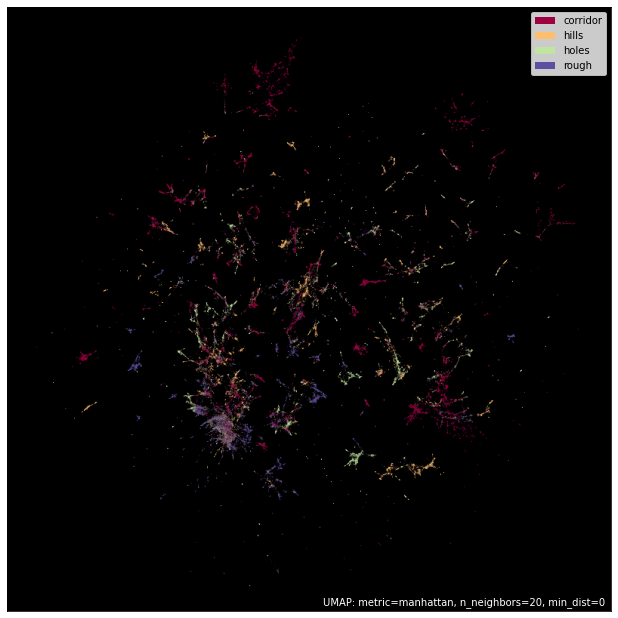

In [251]:
umap.plot.points(mapper_manhattan3, labels=morph_labels, theme='inferno') #values=np.arange(morph_sparse.shape[0]), )

In [252]:
%%time
mapper_manhattan4 = umap.UMAP(metric='manhattan', low_memory=True, n_neighbors=30, min_dist=0).fit(morph_sparse)

CPU times: user 1h 6min 16s, sys: 4.41 s, total: 1h 6min 20s
Wall time: 9min 43s


<Axes: >

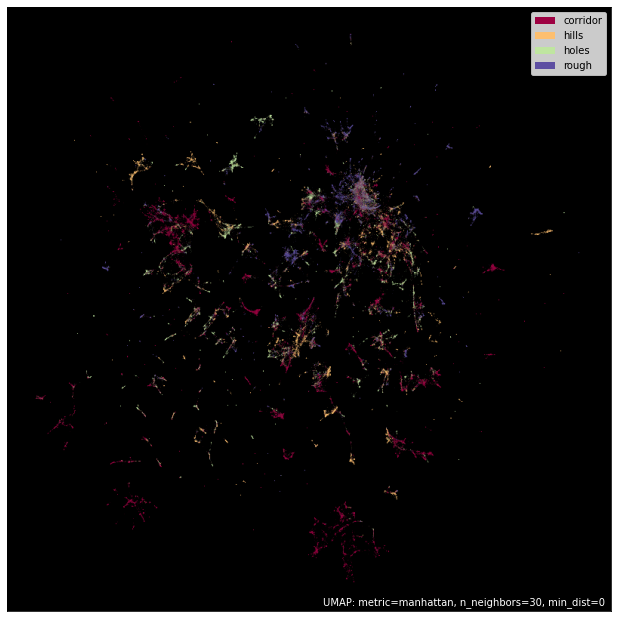

In [253]:
umap.plot.points(mapper_manhattan4, labels=morph_labels, theme='inferno') #values=np.arange(morph_sparse.shape[0]), )

In [254]:
%%time
mapper_manhattan5 = umap.UMAP(metric='manhattan', low_memory=True, n_neighbors=40, min_dist=0).fit(morph_sparse)

CPU times: user 50min 39s, sys: 6.71 s, total: 50min 45s
Wall time: 12min 5s


<Axes: >

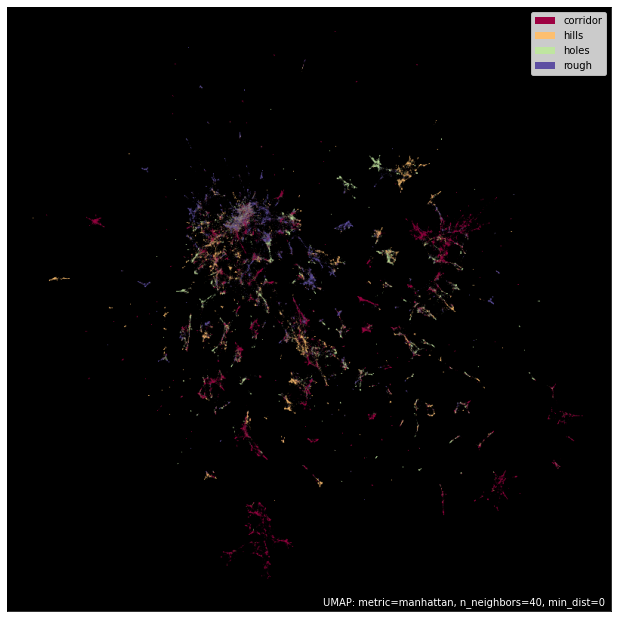

In [255]:
umap.plot.points(mapper_manhattan5, labels=morph_labels, theme='inferno') #values=np.arange(morph_sparse.shape[0]), )

In [256]:
%%time
mapper_manhattan6 = umap.UMAP(metric='manhattan', low_memory=True, n_neighbors=60, min_dist=0).fit(morph_sparse)

CPU times: user 1h 1min 46s, sys: 12.4 s, total: 1h 1min 58s
Wall time: 19min 1s


<Axes: >

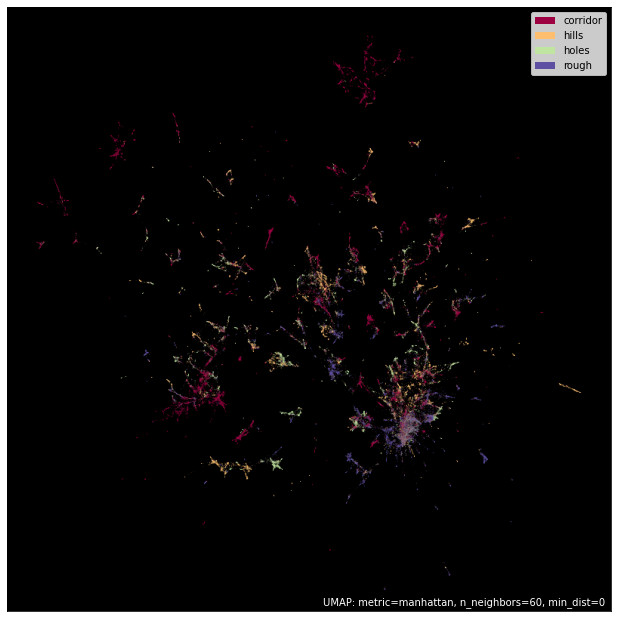

In [257]:
umap.plot.points(mapper_manhattan6, labels=morph_labels, theme='inferno') #values=np.arange(morph_sparse.shape[0]), )

(799.5, -0.5)

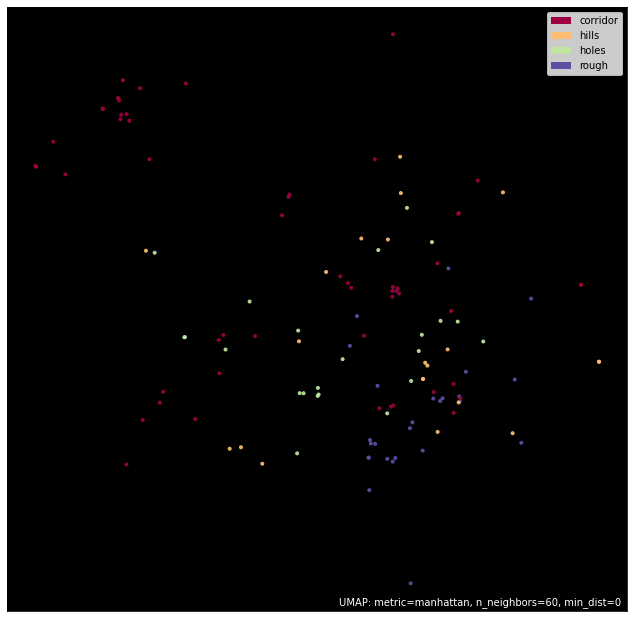

In [275]:
ss = np.greater(morph_fitness, 0.9)
umap.plot.points(mapper_manhattan6, labels=morph_labels, subset_points=ss, theme='inferno',alpha=0.9) #values=np.arange(morph_sparse.shape[0]), )
the_plot.set_xlim(-0.5,799.5)
the_plot.set_ylim(799.5,-0.5)